In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np


# load data
measurement_date = '20260615'
if measurement_date==None:
    today = datetime.today().strftime('%Y%m%d')
else:
    today = measurement_date

output_file = f"../outputs/{today}/measured_rgbs.csv"

df = pd.read_csv(output_file)

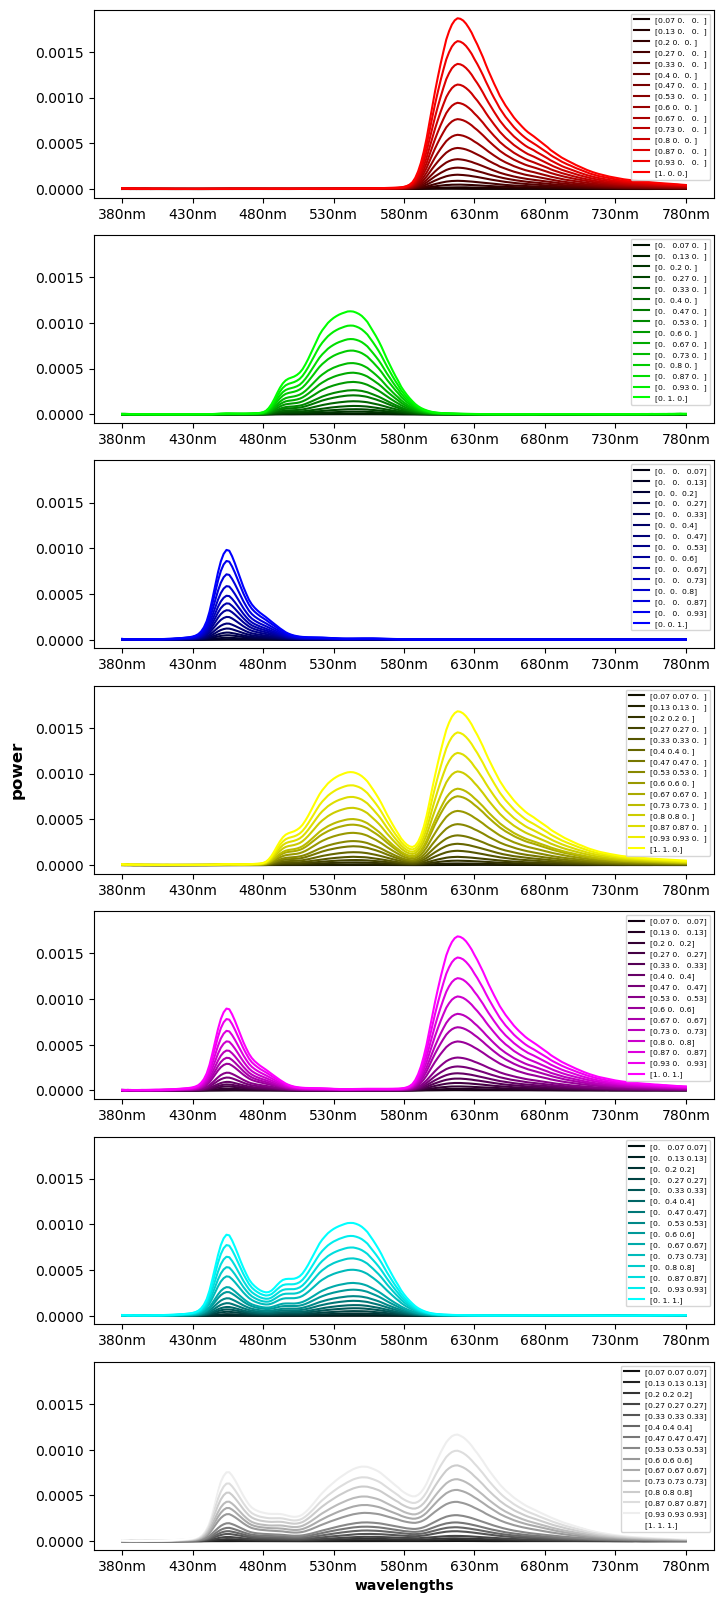

In [2]:
# plot spectra for all the different colour groups
labels = ['R','G','B','Y','M','C','K']

# filter the wavelengths that were measured
column_filter = [c.endswith('nm') for c in df.columns]

n_steps = 15
fig,axs = plt.subplots(int(np.floor(len(df)/n_steps)),1,sharey=True,figsize=(8,20))

for sp_i,sp in enumerate(range(1,len(df),n_steps)):
    ax = axs[sp_i]


    nm_toplot = df.loc[:,column_filter].to_numpy()

    endrange = sp+n_steps
    if endrange > len(df):
        endrange = len(df)
    for i in range(sp,endrange):
        rgb = [df.loc[i,'stim_r'],df.loc[i,'stim_g'],df.loc[i,'stim_b']]
        ax.plot(nm_toplot[i,:],color =rgb,label=str(np.round(rgb,2)))

    ax.legend(fontsize=5.5,)
    ax.set_xticks(np.arange(0,225,25))
    ax.set_xticklabels(df.columns[column_filter].to_numpy()[ax.get_xticks()])

plt.xlabel('wavelengths',weight='bold')
fig.supylabel('power',weight='bold')


plt.savefig(f'../outputs/{today}/measured_rgbs_spectra.png',dpi=600)

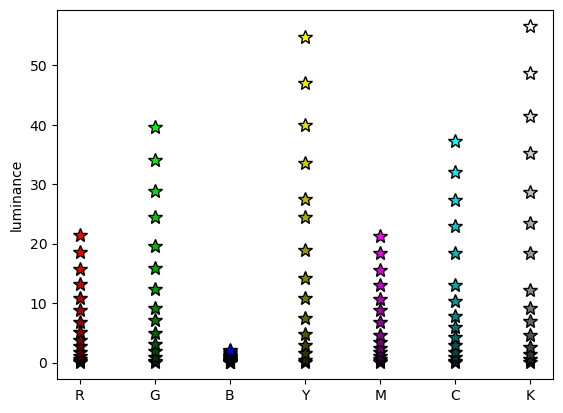

In [3]:
# plot the luminance measured for the different RGBs specified

for sp_i,sp in enumerate(range(1,len(df),n_steps)):
    endrange = sp+n_steps
    if endrange > len(df):
        endrange = len(df)
    for i in range(sp,endrange):
        rgb = [df.loc[i,'stim_r'],df.loc[i,'stim_g'],df.loc[i,'stim_b']]
        plt.plot(labels[sp_i],df.loc[i,'luminance'],'*',color=rgb,markeredgecolor='k',markersize=10)

plt.ylabel('luminance')

plt.savefig(f'../outputs/{today}/measured_rgbs_luminance.png',dpi=600)